In [10]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('/content/drive/MyDrive/VerSe_2020_Dataset/paper_figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'✓ OUTPUT_DIR: {OUTPUT_DIR}')
print(f'  Existe: {OUTPUT_DIR.exists()}')

Mounted at /content/drive
✓ OUTPUT_DIR: /content/drive/MyDrive/VerSe_2020_Dataset/paper_figures
  Existe: True


In [3]:
import wandb
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# Login
wandb.login(key='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')

api    = wandb.Api()
ENTITY  = '0252751-universidad-panamericana'   # ← con el nombre completo
PROJECT = 'verse-spine-segmentation'

runs = api.runs(f'{ENTITY}/{PROJECT}')
print(f'Runs encontrados: {len(runs)}')
for run in runs:
    print(f'  {run.name} | state: {run.state} | tags: {run.tags}')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Runs encontrados: 7
  nnunet-3d-lowres | state: crashed | tags: []
  mednext-3d-lowres | state: finished | tags: []
  nnunet-3d-lowres | state: crashed | tags: []
  nnunet-3d-lowres | state: crashed | tags: []
  mednext-3d-lowres | state: finished | tags: []
  nnunet-3d-lowres-completo | state: finished | tags: []
  mednext-3d-lowres-completo | state: finished | tags: []


In [4]:
# Ver métricas disponibles en cada run finished
for run in api.runs(f'{ENTITY}/{PROJECT}'):
    if run.state == 'finished':
        print(f'\n── {run.name} ──────────────────────')
        # Ver primeras keys del historial
        history = run.history(samples=5)
        print(f'  Columnas: {list(history.columns)[:15]}')
        print(f'  Filas: {len(run.history())}')


── mednext-3d-lowres ──────────────────────
  Columnas: ['gpu/utilization_pct', '_step', 'val/loss', 'system/cpu_pct', 'val/ema_pseudo_dice', '_timestamp', 'fold', 'train/loss', 'gpu/vram_used_gb', 'system/ram_used_gb', 'epoch', 'train/lr', 'train/epoch_time_s', 'fold_fallido', 'gpu/vram_total_gb']
  Filas: 500

── mednext-3d-lowres ──────────────────────
  Columnas: ['fold', 'train/lr', 'system/ram_used_pct', 'gpu/vram_total_gb', 'gpu/vram_used_pct', 'val/loss', 'system/cpu_pct', 'gpu/utilization_pct', 'fold_fallido', 'val/ema_pseudo_dice', 'epoch', 'train/loss', '_step', '_runtime', 'gpu/temperature_c']
  Filas: 500

── nnunet-3d-lowres-completo ──────────────────────
  Columnas: ['_timestamp', 'train/loss', 'val/loss', '_step', 'epoch', 'train/epoch_time_s', 'val/ema_pseudo_dice', 'fold', '_runtime', 'train/lr']
  Filas: 500

── mednext-3d-lowres-completo ──────────────────────
  Columnas: ['train/epoch_time_s', '_step', 'train/lr', 'val/loss', '_timestamp', 'train/loss', 'epoch', 

In [7]:
# ── Descargar datos de todos los runs finished ─────────────────────────────
model_runs = {
    'nnUNet':   [],
    'MedNeXt':  [],
}

for run in api.runs(f'{ENTITY}/{PROJECT}'):
    if run.state == 'finished':
        df = run.history(samples=10000)
        df['run_name'] = run.name
        if 'nnunet' in run.name:
            model_runs['nnUNet'].append(df)
        elif 'mednext' in run.name:
            model_runs['MedNeXt'].append(df)

for model, dfs in model_runs.items():
    print(f'{model}: {len(dfs)} runs, '
          f'{sum(len(d) for d in dfs)} filas totales')

nnUNet: 1 runs, 1250 filas totales
MedNeXt: 3 runs, 2503 filas totales


nnUNet: 1 runs
  nnunet-3d-lowres-completo — 1250 filas
MedNeXt: 3 runs
  mednext-3d-lowres — 503 filas
  mednext-3d-lowres — 750 filas
  mednext-3d-lowres-completo — 1250 filas


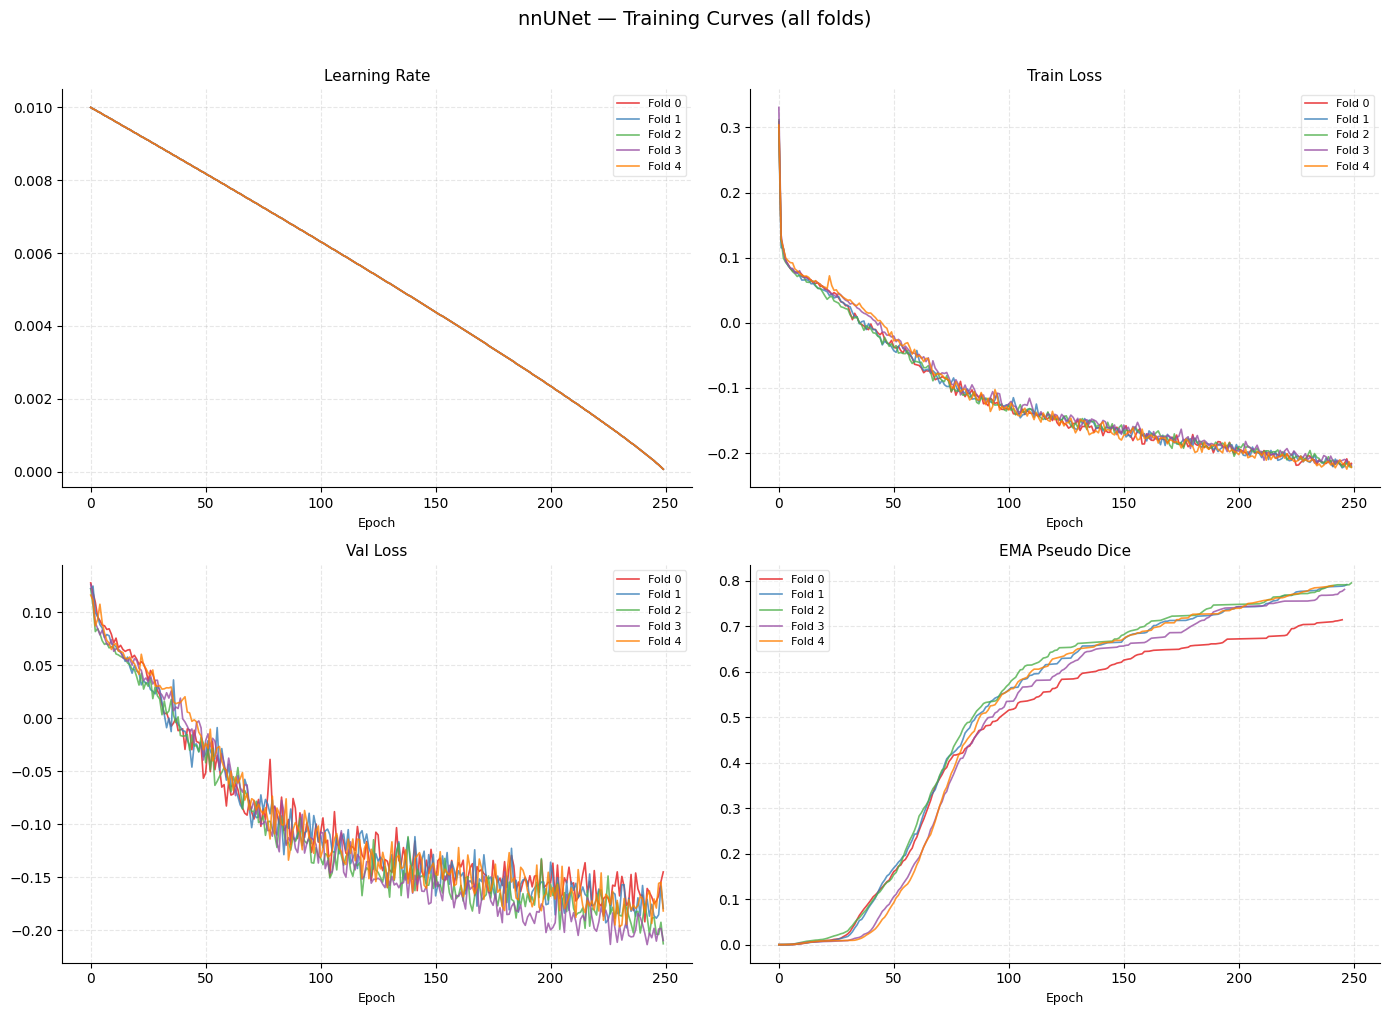

✓ Guardado → /content/drive/MyDrive/VerSe_2020_Dataset/paper_figures/fig_wandb_nnunet.png


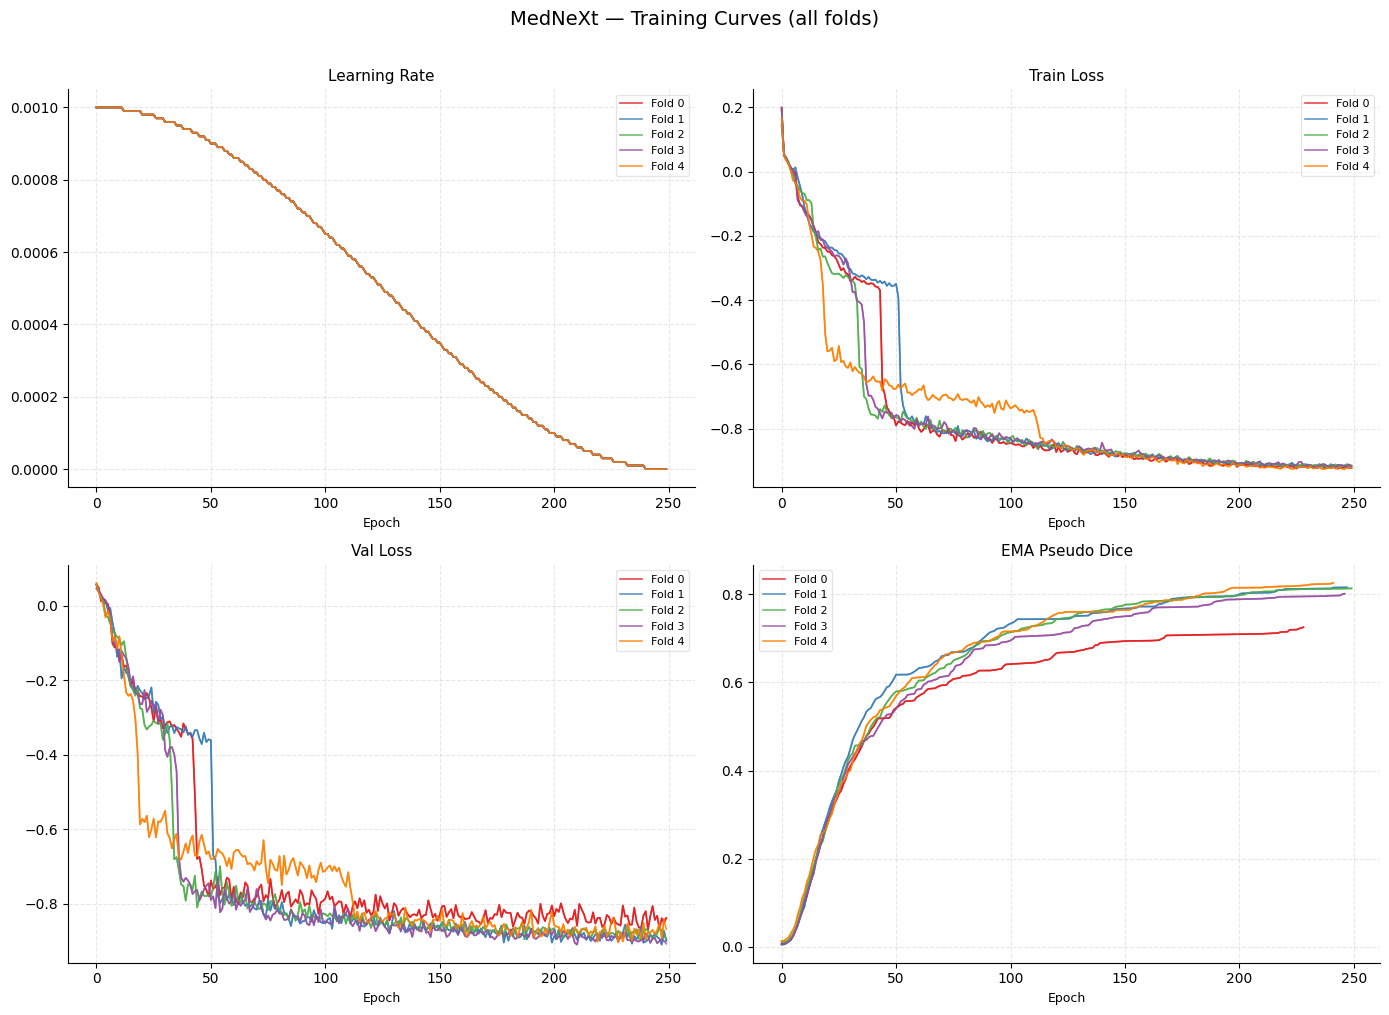

✓ Guardado → /content/drive/MyDrive/VerSe_2020_Dataset/paper_figures/fig_wandb_mednext.png


In [19]:
from pathlib import Path
import matplotlib.pyplot as plt

METRICS = [
    ('train/lr',           'Learning Rate'),
    ('train/loss',         'Train Loss'),
    ('val/loss',           'Val Loss'),
    ('val/ema_pseudo_dice','EMA Pseudo Dice'),
]

COLORS  = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']
OUTPUT_DIR = Path('/content/drive/MyDrive/VerSe_2020_Dataset/paper_figures')

# ── Agrupar runs por modelo incluyendo "completo" ──────────────────────────
model_runs_all = {
    'nnUNet':  [],
    'MedNeXt': [],
}

for run in api.runs(f'{ENTITY}/{PROJECT}'):
    if run.state != 'finished':
        continue
    df = run.history(samples=10000)
    df['run_name'] = run.name
    if 'nnunet' in run.name:
        model_runs_all['nnUNet'].append(df)
    elif 'mednext' in run.name:
        model_runs_all['MedNeXt'].append(df)

for model, dfs in model_runs_all.items():
    print(f'{model}: {len(dfs)} runs')
    for df in dfs:
        print(f'  {df["run_name"].iloc[0]} — {len(df)} filas')

# ── Generar figura por modelo ──────────────────────────────────────────────
for model_name, dfs in model_runs_all.items():
    if not dfs:
        continue

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
    fig.suptitle(f'{model_name} — Training Curves (all folds)',
                 fontsize=14, color='black', y=1.01)

    for ax, (metric, title) in zip(axes.flatten(), METRICS):
        ax.set_facecolor('white')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        color_idx = 0
        for df in dfs:
            if metric not in df.columns:
                continue
            x_col = 'epoch' if 'epoch' in df.columns else '_step'

            if 'fold' in df.columns:
                for fold_id, fold_df in df.groupby('fold'):
                    fold_data = fold_df[[x_col, metric]].dropna()
                    if fold_data.empty:
                        continue

                    # Filtrar outliers en EMA Pseudo Dice
                    if metric == 'val/ema_pseudo_dice':
                        fold_data = fold_data[fold_data[metric] <= 1.0]

                    color = COLORS[int(fold_id) % len(COLORS)]
                    run_label = df['run_name'].iloc[0]
                    label = f'Fold {int(fold_id)}'

                    ax.plot(fold_data[x_col], fold_data[metric],
                            color=color, alpha=0.8, linewidth=1.2,
                            label=label)
            else:
                data = df[[x_col, metric]].dropna()
                if metric == 'val/ema_pseudo_dice':
                    data = data[data[metric] <= 1.0]
                color = COLORS[color_idx % len(COLORS)]
                color_idx += 1
                ax.plot(data[x_col], data[metric],
                        color=color, alpha=0.8, linewidth=1.2,
                        label=df['run_name'].iloc[0])

        ax.set_title(title, fontsize=11, color='black', pad=6)
        ax.set_xlabel('Epoch', fontsize=9, color='black')
        ax.tick_params(colors='black')

        # Evitar leyendas duplicadas
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(),
                  fontsize=8, framealpha=0.5)
        ax.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    out_path = str(OUTPUT_DIR / f'fig_wandb_{model_name.lower()}.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'✓ Guardado → {out_path}')

In [13]:
for run in api.runs(f'{ENTITY}/{PROJECT}'):
    if run.name == 'nnunet-3d-lowres-completo':
        df = run.history(samples=10000)
        print(f'Columnas: {list(df.columns)}')
        print(f'Filas: {len(df)}')
        if 'fold' in df.columns:
            print(f'Folds únicos: {df["fold"].unique()}')
        print(df.head(10))

Columnas: ['_timestamp', 'train/loss', 'val/loss', '_step', 'epoch', 'train/epoch_time_s', 'val/ema_pseudo_dice', 'fold', '_runtime', 'train/lr']
Filas: 1250
Folds únicos: [0 1 2 3 4]
     _timestamp  train/loss  val/loss  _step  epoch  train/epoch_time_s  \
0  1.777970e+09      0.3085    0.1278      0      0               99.57   
1  1.777970e+09      0.1268    0.1185      1      1               50.98   
2  1.777970e+09      0.1130    0.1097      2      2               50.94   
3  1.777970e+09      0.0961    0.0959      3      3               50.80   
4  1.777970e+09      0.0896    0.0923      4      4               51.23   
5  1.777970e+09      0.0833    0.0879      5      5               50.98   
6  1.777970e+09      0.0797    0.0874      6      6               50.95   
7  1.777970e+09      0.0781    0.0839      7      7               51.12   
8  1.777970e+09      0.0778    0.0845      8      8               51.01   
9  1.777970e+09      0.0777    0.0793      9      9               

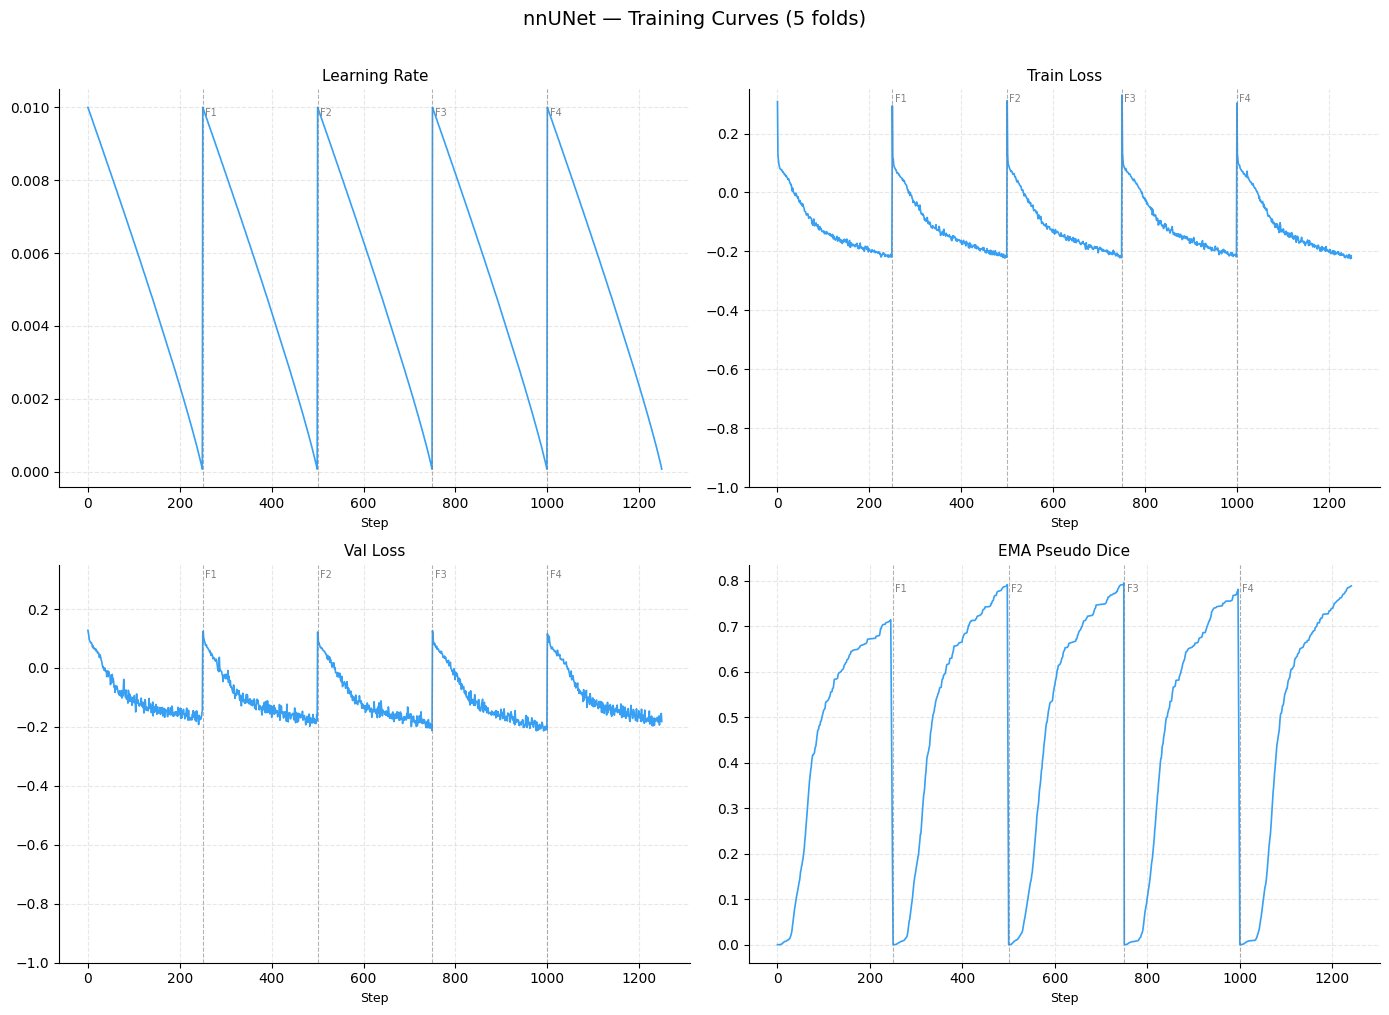

✓ Guardado → /content/drive/MyDrive/VerSe_2020_Dataset/paper_figures/fig_wandb_nnunet_5folds.png


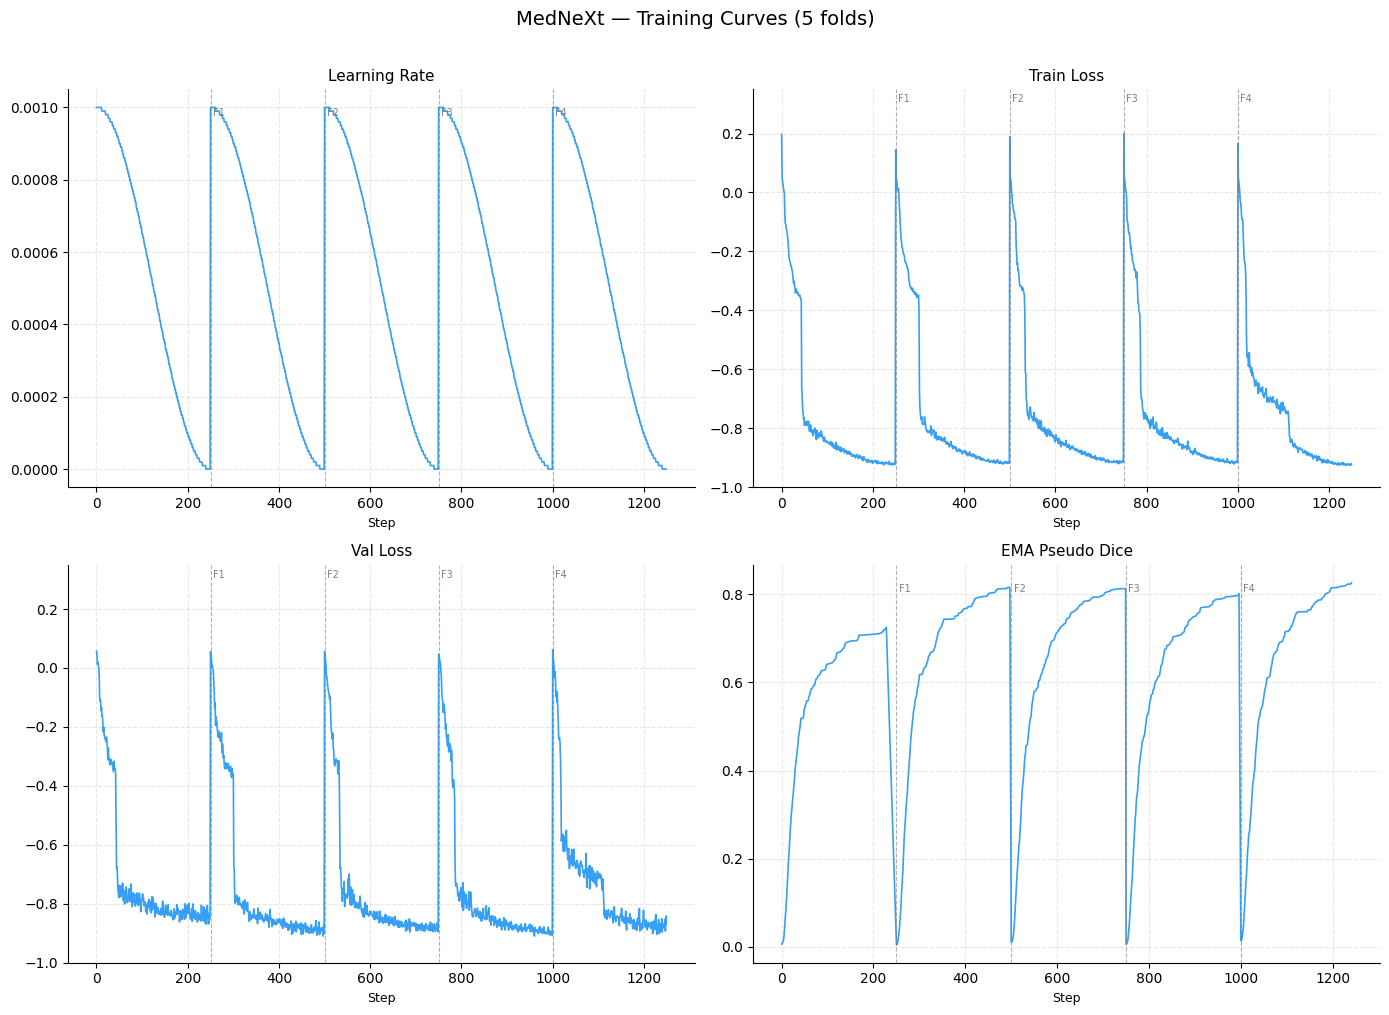

✓ Guardado → /content/drive/MyDrive/VerSe_2020_Dataset/paper_figures/fig_wandb_mednext_5folds.png


In [18]:
from pathlib import Path
import matplotlib.pyplot as plt

METRICS = [
    ('train/lr',           'Learning Rate'),
    ('train/loss',         'Train Loss'),
    ('val/loss',           'Val Loss'),
    ('val/ema_pseudo_dice','EMA Pseudo Dice'),
]

COLORS     = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']
OUTPUT_DIR = Path('/content/drive/MyDrive/VerSe_2020_Dataset/paper_figures')

# ── Separar runs: completo vs parciales ───────────────────────────────────
runs_completo = {'nnUNet': None, 'MedNeXt': None}
runs_parciales = {'nnUNet': [], 'MedNeXt': []}

for run in api.runs(f'{ENTITY}/{PROJECT}'):
    if run.state != 'finished':
        continue
    df = run.history(samples=10000)
    df['run_name'] = run.name

    if 'nnunet' in run.name:
        if 'completo' in run.name:
            runs_completo['nnUNet'] = df
        else:
            runs_parciales['nnUNet'].append(df)
    elif 'mednext' in run.name:
        if 'completo' in run.name:
            runs_completo['MedNeXt'] = df
        else:
            runs_parciales['MedNeXt'].append(df)

# ── Figura por modelo ──────────────────────────────────────────────────────
for model_name in ['nnUNet', 'MedNeXt']:
    df_completo = runs_completo[model_name]
    if df_completo is None:
        print(f'⚠ Sin run completo para {model_name}')
        continue

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
    fig.suptitle(f'{model_name} — Training Curves (5 folds)',
                 fontsize=14, color='black', y=1.01)

    for ax, (metric, title) in zip(axes.flatten(), METRICS):
        ax.set_facecolor('white')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if metric not in df_completo.columns:
            ax.set_title(title, fontsize=11)
            ax.axis('off')
            continue

        # Usar _step como eje X para ver los 5 folds consecutivos
        data = df_completo[['_step', metric]].dropna()

        if metric == 'val/ema_pseudo_dice':
            data = data[data[metric] <= 1.0]

        ax.plot(data['_step'], data[metric],
                color='#2196F3', linewidth=1.2, alpha=0.9)

        # Fijar eje Y para loss
        if metric == 'train/loss' or metric == 'val/loss':
            if model_name == 'nnUNet':
                ax.set_ylim(-1.0, 0.35)   # ← llega hasta -1
            elif model_name == 'MedNeXt':
                ax.set_ylim(-1.0, 0.35)   # ← mismo rango para comparar

        # Líneas verticales en cada cambio de fold
        if 'fold' in df_completo.columns:
            fold_changes = df_completo.groupby('fold')['_step'].min()
            for fold_id, step in fold_changes.items():
                if fold_id == 0:
                    continue
                ax.axvline(x=step, color='gray', linestyle='--',
                           linewidth=0.8, alpha=0.6)
                ax.text(step + 5, ax.get_ylim()[1] * 0.95,
                        f'F{int(fold_id)}', fontsize=7,
                        color='gray', va='top')

        ax.set_title(title, fontsize=11, color='black', pad=6)
        ax.set_xlabel('Step', fontsize=9, color='black')
        ax.tick_params(colors='black')
        ax.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    out_path = str(OUTPUT_DIR / f'fig_wandb_{model_name.lower()}_5folds.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'✓ Guardado → {out_path}')

In [20]:
import wandb

# Login con la key de Cristian
wandb.login(key='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')

api_cristian = wandb.Api()

ENTITY_SWIN  = 'kurisari-universidad-panamericana'
PROJECT_SWIN = 'verse-spine-segmentation'

# Verificar proyecto
try:
    runs = api_cristian.runs(f'{ENTITY_SWIN}/{PROJECT_SWIN}')
    print(f'Runs encontrados: {len(runs)}')
    for run in runs:
        print(f'  {run.name} | state: {run.state} | tags: {run.tags}')
except Exception as e:
    print(f'⚠ Error: {e}')
    # Buscar proyectos disponibles
    projects = api_cristian.projects(entity=ENTITY_SWIN)
    print(f'\nProyectos disponibles:')
    for p in projects:
        print(f'  {p.name}')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kurisari (kurisari-universidad-panamericana) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Runs encontrados: 9
  swinunetr-3d-lowres | state: finished | tags: []
  swinunetr-3d-lowres | state: finished | tags: []
  swinunetr-3d-lowres | state: crashed | tags: []
  swinunetr-3d-lowres | state: crashed | tags: []
  swinunetr-3d-lowres | state: crashed | tags: []
  swinunetr-3d-lowres | state: finished | tags: []
  swinunetr-3d-lowres-sync | state: finished | tags: []
  swinunetr-sync | state: finished | tags: []
  swinunetr-sync | state: finished | tags: []


In [21]:
for run in api_cristian.runs(f'{ENTITY_SWIN}/{PROJECT_SWIN}'):
    if run.state == 'finished':
        df = run.history(samples=5)
        folds = df['fold'].unique() if 'fold' in df.columns else 'sin fold'
        filas = len(run.history(samples=10000))
        print(f'  {run.name} | filas: {filas} | folds: {folds} | cols: {list(df.columns)[:8]}')

  swinunetr-3d-lowres | filas: 1 | folds: sin fold | cols: ['fold_fallido', '_step', '_runtime', '_timestamp']
  swinunetr-3d-lowres | filas: 3 | folds: sin fold | cols: ['_timestamp', 'fold_fallido', '_step', '_runtime']
  swinunetr-3d-lowres | filas: 5 | folds: sin fold | cols: ['_timestamp', 'fold_fallido', '_step', '_runtime']
  swinunetr-3d-lowres-sync | filas: 0 | folds: sin fold | cols: []
  swinunetr-sync | filas: 0 | folds: sin fold | cols: []
  swinunetr-sync | filas: 74 | folds: sin fold | cols: ['_step', 'epoch', '_runtime', 'val/loss', '_timestamp', 'train/loss', 'val/ema_pseudo_dice']


In [22]:
import re
import pandas as pd
from pathlib import Path

DRIVE_BASE = '/content/drive/MyDrive/VerSe_2020_Dataset'

LOG_DIR_SWIN = Path(DRIVE_BASE) / 'SwinUNETR_training/swinunetr/Dataset507_VerSe2020/nnUNetTrainerSwinUNETR_250epochs__nnUNetPlans__3d_lowres'

# Ver qué folds hay
print('Folds disponibles:')
for fold_dir in sorted(LOG_DIR_SWIN.glob('fold_*')):
    logs = list(fold_dir.glob('training_log*.txt'))
    print(f'  {fold_dir.name}: {[l.name for l in logs]}')

Folds disponibles:
  fold_0: ['training_log_2026_5_5_18_48_55.txt', 'training_log_2026_5_6_00_07_44.txt', 'training_log_2026_5_5_20_40_51.txt']
  fold_1: ['training_log_2026_5_6_12_11_05.txt']
  fold_2: ['training_log_2026_5_7_03_12_52.txt']
  fold_3: ['training_log_2026_5_7_18_14_39.txt']
  fold_4: ['training_log_2026_5_8_09_15_22.txt']


Fold 0: 250 epochs | train_loss final: -0.1285 | ema_dice final: 0.6641
Fold 1: 250 epochs | train_loss final: -0.1217 | ema_dice final: 0.7331
Fold 2: 250 epochs | train_loss final: -0.1273 | ema_dice final: 0.7305
Fold 3: 250 epochs | train_loss final: -0.1296 | ema_dice final: 0.7233
Fold 4: 250 epochs | train_loss final: -0.1294 | ema_dice final: 0.7314


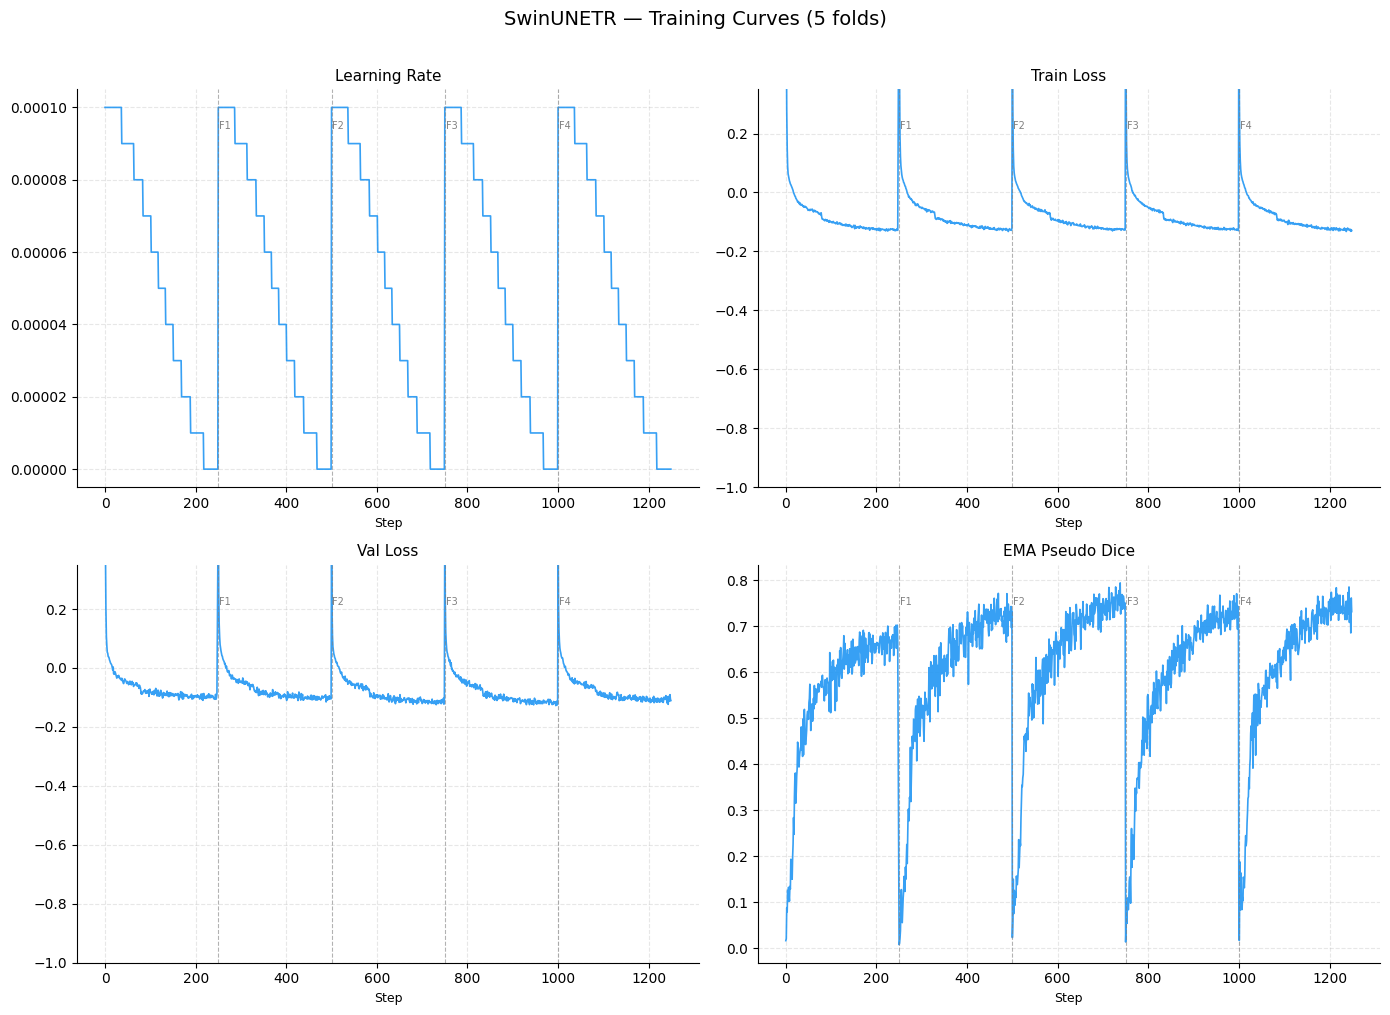

✓ Guardado → /content/drive/MyDrive/VerSe_2020_Dataset/paper_figures/fig_wandb_swinunetr_5folds.png


In [28]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DRIVE_BASE   = '/content/drive/MyDrive/VerSe_2020_Dataset'
OUTPUT_DIR   = Path(f'{DRIVE_BASE}/paper_figures')
LOG_DIR_SWIN = Path(DRIVE_BASE) / 'SwinUNETR_training/swinunetr/Dataset507_VerSe2020/nnUNetTrainerSwinUNETR_250epochs__nnUNetPlans__3d_lowres'

def parse_fold_log(fold_dir):
    logs    = sorted(fold_dir.glob('training_log*.txt'))
    records = []

    for log_path in logs:
        with open(log_path) as f:
            content = f.read()

        lines = content.split('\n')
        i = 0
        while i < len(lines):
            # Buscar línea de epoch
            epoch_match = re.search(r'Epoch (\d+)$', lines[i].strip())
            if epoch_match:
                epoch = int(epoch_match.group(1))
                rec   = {'epoch': epoch}

                # Buscar en las siguientes 10 líneas
                window = '\n'.join(lines[i:i+10])

                lr = re.search(r'Current learning rate: ([\d.e+-]+)', window)
                tl = re.search(r'train_loss ([-\d.]+)', window)
                vl = re.search(r'val_loss ([-\d.]+)', window)
                et = re.search(r'Epoch time: ([\d.]+) s', window)
                db = re.search(r'Pseudo dice \[([^\]]+)\]', window)

                rec['lr']         = float(lr.group(1)) if lr else None
                rec['train_loss'] = float(tl.group(1)) if tl else None
                rec['val_loss']   = float(vl.group(1)) if vl else None
                rec['epoch_time'] = float(et.group(1)) if et else None

                if db:
                    vals = re.findall(r'([\d.]+)\)', db.group(1))
                    vals = [float(v) for v in vals if 0.0 < float(v) <= 1.0]
                    rec['ema_dice'] = np.mean(vals) if vals else None
                else:
                    rec['ema_dice'] = None

                records.append(rec)
            i += 1

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)
    df = df.drop_duplicates('epoch').sort_values('epoch').reset_index(drop=True)
    return df

# ── Parsear los 5 folds ────────────────────────────────────────────────────
fold_dfs = {}
for fold_dir in sorted(LOG_DIR_SWIN.glob('fold_*')):
    fold_id = int(fold_dir.name.split('_')[1])
    df      = parse_fold_log(fold_dir)
    fold_dfs[fold_id] = df
    if not df.empty:
        print(f'Fold {fold_id}: {len(df)} epochs | '
              f'train_loss final: {df["train_loss"].dropna().iloc[-1]:.4f} | '
              f'ema_dice final: {df["ema_dice"].dropna().iloc[-1]:.4f}')
    else:
        print(f'Fold {fold_id}: vacío')

# ── Figura SwinUNETR ───────────────────────────────────────────────────────
METRICS_LOG = [
    ('lr',         'Learning Rate'),
    ('train_loss', 'Train Loss'),
    ('val_loss',   'Val Loss'),
    ('ema_dice',   'EMA Pseudo Dice'),
]
COLORS = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

# Step global continuo
step_offset = 0
fold_steps  = {}
for fold_id in sorted(fold_dfs.keys()):
    n = len(fold_dfs[fold_id])
    fold_steps[fold_id] = step_offset
    step_offset += n

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
fig.suptitle('SwinUNETR — Training Curves (5 folds)',
             fontsize=14, color='black', y=1.01)

for ax, (metric, title) in zip(axes.flatten(), METRICS_LOG):
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Concatenar todos los folds en una sola curva continua
    all_x, all_y = [], []
    for fold_id in sorted(fold_dfs.keys()):
        df   = fold_dfs[fold_id]
        data = df[['epoch', metric]].dropna()
        if data.empty:
            continue
        start = fold_steps[fold_id]
        x     = np.arange(start, start + len(data))
        all_x.extend(x.tolist())
        all_y.extend(data[metric].values.tolist())

    if all_x:
        ax.plot(all_x, all_y, color='#2196F3', linewidth=1.2, alpha=0.9)

    if metric in ('train_loss', 'val_loss'):
        ax.set_ylim(-1.0, 0.35)

    # Líneas verticales entre folds
    ymin, ymax = ax.get_ylim()
    for fold_id in range(1, 5):
        step = fold_steps[fold_id]
        ax.axvline(x=step, color='gray', linestyle='--',
                   linewidth=0.8, alpha=0.6)
        ax.text(step + 2, ymin + (ymax - ymin) * 0.92,
                f'F{fold_id}', fontsize=7, color='gray', va='top')

    ax.set_title(title, fontsize=11, color='black', pad=6)
    ax.set_xlabel('Step', fontsize=9, color='black')
    ax.tick_params(colors='black')
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
out_path = str(OUTPUT_DIR / 'fig_wandb_swinunetr_5folds.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ Guardado → {out_path}')

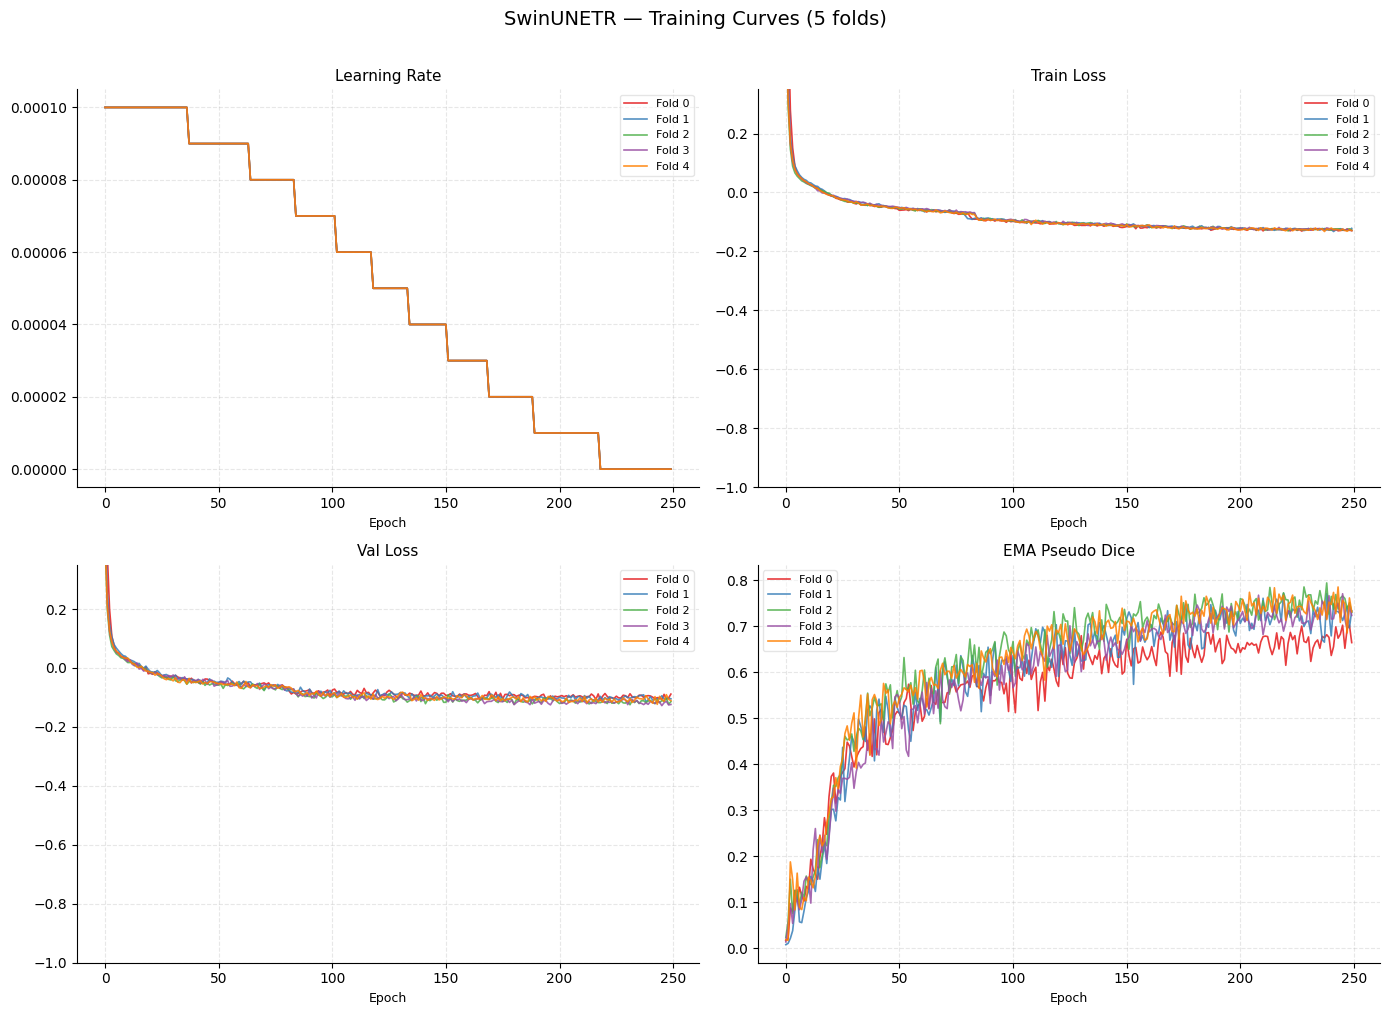

✓ Guardado → /content/drive/MyDrive/VerSe_2020_Dataset/paper_figures/fig_wandb_swinunetr.png


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')
fig.suptitle('SwinUNETR — Training Curves (5 folds)',
             fontsize=14, color='black', y=1.01)

METRICS_LOG = [
    ('lr',         'Learning Rate'),
    ('train_loss', 'Train Loss'),
    ('val_loss',   'Val Loss'),
    ('ema_dice',   'EMA Pseudo Dice'),
]
COLORS = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00']

for ax, (metric, title) in zip(axes.flatten(), METRICS_LOG):
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for fold_id in sorted(fold_dfs.keys()):
        df   = fold_dfs[fold_id]
        data = df[['epoch', metric]].dropna()
        if data.empty:
            continue

        color = COLORS[fold_id % len(COLORS)]
        ax.plot(data['epoch'], data[metric].values,
                color=color, linewidth=1.2, alpha=0.85,
                label=f'Fold {fold_id}')

    if metric in ('train_loss', 'val_loss'):
        ax.set_ylim(-1.0, 0.35)

    ax.set_title(title, fontsize=11, color='black', pad=6)
    ax.set_xlabel('Epoch', fontsize=9, color='black')
    ax.tick_params(colors='black')
    ax.legend(fontsize=8, framealpha=0.5)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
out_path = str(OUTPUT_DIR / 'fig_wandb_swinunetr.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ Guardado → {out_path}')